# Importing necessary modules

In [17]:
import pickle
import os
import mediapipe as mp
import cv2
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


# Data Loading and Preprocessing

In [18]:
# Mediapipe setup
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.3)


In [19]:
# Data directory and containers
DATA_DIR = 'dataset'
data = []
labels = []

In [20]:
# Process each item in the dataset directory
for dir_ in os.listdir(DATA_DIR):
    dir_path = os.path.join(DATA_DIR, dir_)
    if os.path.isdir(dir_path):  # Check if it is a directory
        for img_path in os.listdir(dir_path):
            data_aux = []
            img = cv2.imread(os.path.join(dir_path, img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Flip the image horizontally
            img_flipped = cv2.flip(img_rgb, 1)
            
            for img_variant in [img_rgb, img_flipped]:  # Use original and flipped images
                data_aux = []
                results = hands.process(img_variant)
                if results.multi_hand_landmarks:
                    for hand_landmarks in results.multi_hand_landmarks:
                        for i in range(len(hand_landmarks.landmark)):
                            x = hand_landmarks.landmark[i].x
                            y = hand_landmarks.landmark[i].y
                            data_aux.append(x)
                            data_aux.append(y)
                    # Ensure the feature vector length is consistent
                    if len(data_aux) == 42:  # 21 landmarks * 2 (x, y)
                        data.append(data_aux)
                        labels.append(dir_)

In [21]:
# Convert labels to numerical format
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Convert data to numpy array
data = np.array(data)

In [22]:
# Scale the data
scaler = StandardScaler()
data = scaler.fit_transform(data)

# Save the preprocessed data
with open('preprocessed_data.pickle', 'wb') as f:
    pickle.dump((data, labels), f)

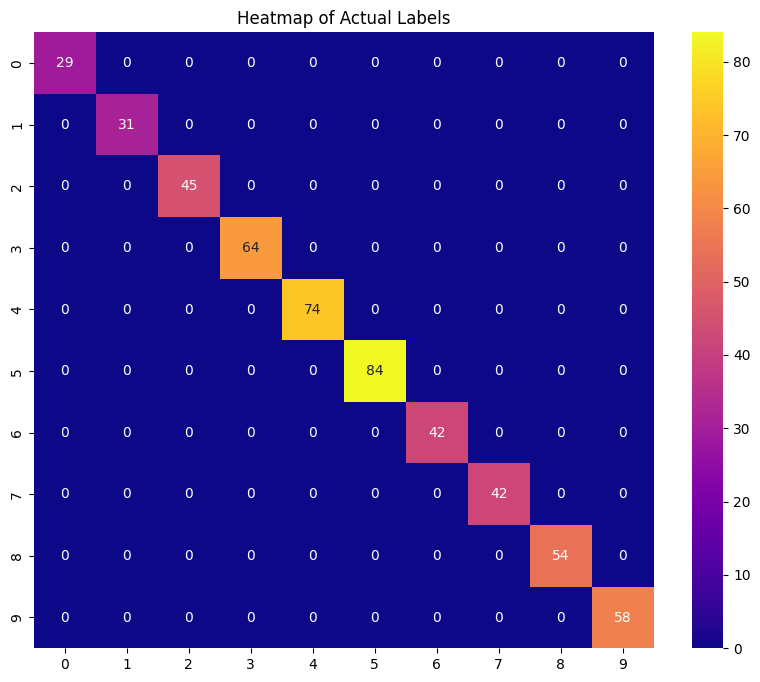

In [23]:
# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(labels, labels), annot=True, cmap="plasma", fmt='g')
plt.title('Heatmap of Actual Labels')
plt.show()

# Training

In [24]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, shuffle=True, stratify=labels)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Save the trained model and scaler
with open('logistic_regression_sign_language_model.pickle', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

# Evaluation

In [25]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 93.33%


In [26]:
# Additional evaluation metrics
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')

              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.80      0.67      0.73         6
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        13
           4       0.93      0.87      0.90        15
           5       0.84      0.94      0.89        17
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      0.92      0.96        12

    accuracy                           0.93       105
   macro avg       0.93      0.92      0.92       105
weighted avg       0.94      0.93      0.93       105

Confusion Matrix:
[[ 5  1  0  0  0  0  0  0  0  0]
 [ 2  4  0  0  0  0  0  0  0  0]
 [ 0  0  9  0  0  0  0  0  0  0]
 [ 0  0  0 13  0  0  0  0  0  0]
 [ 0  0  0  0 13  2  0  0  0  0]
 [ 0  0  0  0  1 16  0  0  0  0]
 [ 0  0  0  0  0  0  8  0

In [27]:
# Cross-validation
cv_scores = cross_val_score(model, data, labels, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean()}')


Cross-Validation Accuracy Scores: [0.94285714 0.94285714 0.92380952 0.81730769 0.94230769]
Mean Cross-Validation Accuracy: 0.9138278388278389


In [28]:
# Save the trained model and scaler
with open('logistic_regression_sign_language_model.pickle', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

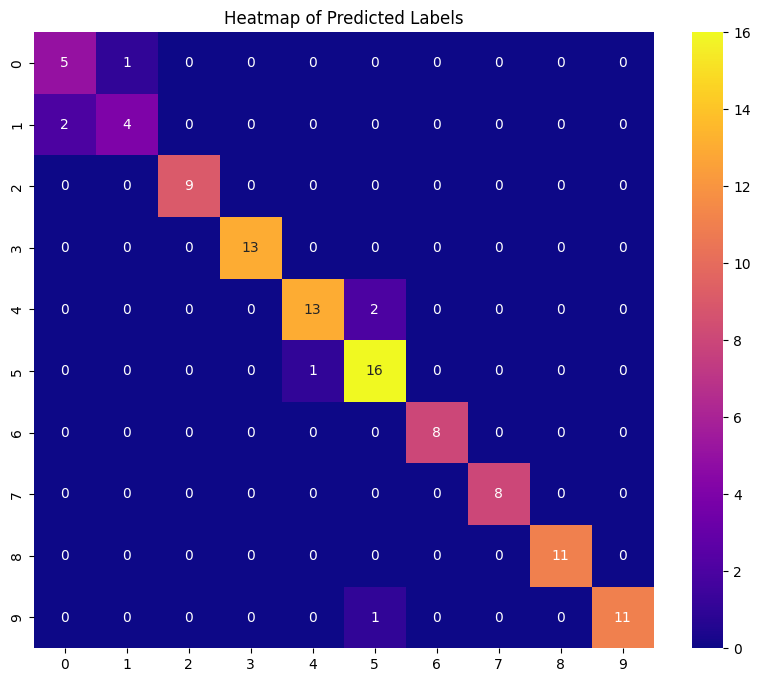

In [29]:
# Generate heatmap for predictions
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="plasma", fmt='g')
plt.title('Heatmap of Predicted Labels')
plt.show()

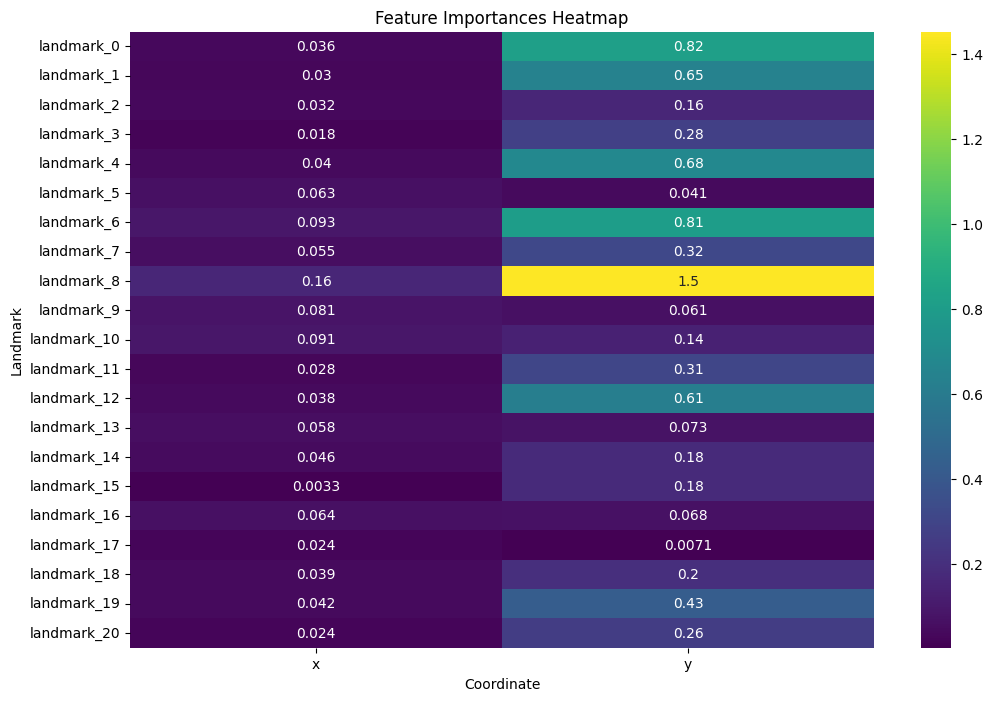

In [30]:
# Load the trained model and scaler
model = pickle.load(open('logistic_regression_sign_language_model.pickle', 'rb'))
scaler = pickle.load(open('scaler.pickle', 'rb'))

# Since LogisticRegression doesn't have feature_importances_, we'll use the coefficients
# Get the absolute value of the coefficients
importances = np.abs(model.coef_[0])

# Reshape the importances to correspond to the (x, y) coordinates of the landmarks
importances = importances.reshape((21, 2))

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(importances, annot=True, cmap='viridis', xticklabels=['x', 'y'], yticklabels=[f'landmark_{i}' for i in range(21)])
plt.title('Feature Importances Heatmap')
plt.xlabel('Coordinate')
plt.ylabel('Landmark')
plt.show()

# Visualization

In [31]:
# Calculate and print the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.20952380952380953


# Real Time Prediction Phase 

In [32]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='google.protobuf.symbol_database')

# Load the trained model and scaler
model = pickle.load(open('logistic_regression_sign_language_model.pickle', 'rb'))
scaler = pickle.load(open('scaler.pickle', 'rb'))

# Initialize video capture
cap = cv2.VideoCapture(0)

while True:
    x_ = []
    y_ = []
    data_aux = []
    ret, frame = cap.read()
    H, W, _ = frame.shape
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
    results = hands.process(frame_rgb)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )
            for i in range(len(hand_landmarks.landmark)):
                x = hand_landmarks.landmark[i].x
                y = hand_landmarks.landmark[i].y
                data_aux.append(x)
                data_aux.append(y)  
                x_.append(x)
                y_.append(y)
                    
        x1 = int(min(x_) * W) - 10
        y1 = int(min(y_) * H) - 10
        x2 = int(max(x_) * W) - 10
        y2 = int(max(y_) * H) - 10
        if len(data_aux) == 42:  # Ensure the feature vector length is consistent
            data_aux = scaler.transform([np.asarray(data_aux)])  # Scale the data
            prediction = model.predict(data_aux)
            predicted_character = label_encoder.inverse_transform([int(prediction[0])])[0]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 0), 4)
            cv2.putText(frame, predicted_character, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 0), 3, cv2.LINE_AA)
        
    cv2.imshow('frame', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()